In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# Plotting defaults
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

print("All libraries loaded successfully!")


All libraries loaded successfully!


In [2]:
df_raw = pd.read_excel(r"C:\Users\ASUS\Downloads\online+retail\Online Retail.xlsx")
print(f"Loaded locally: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")

Loaded locally: 541,909 rows, 8 columns


In [3]:
df = df_raw.copy()

print("=== INITIAL DATA QUALITY ===")
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicates: {df.duplicated().sum()}")

# Removing rows with missing CustomerID (can't track customer behavior)
df = df.dropna(subset=['CustomerID'])

# Removing cancelled orders (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Removing zero or negative prices and quantities (returns/errors)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Removing extreme outliers (prices > £500 and quantities > 500 per line item)
df = df[(df['UnitPrice'] <= 500) & (df['Quantity'] <= 500)]

# Creating Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Parsing dates
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Date'] = df['InvoiceDate'].dt.date
df['Month'] = df['InvoiceDate'].dt.month
df['Quarter'] = df['InvoiceDate'].dt.quarter
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek  # 0=Monday
df['Hour'] = df['InvoiceDate'].dt.hour

print(f"\n=== AFTER CLEANING ===")
print(f"Shape: {df.shape}")
print(f"Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
print(f"Countries: {df['Country'].nunique()}")
print(f"Products: {df['StockCode'].nunique()}")
print(f"Customers: {df['CustomerID'].nunique()}")


=== INITIAL DATA QUALITY ===
Shape: (541909, 8)

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicates: 5268

=== AFTER CLEANING ===
Shape: (397436, 14)
Date range: 2010-12-01 to 2011-12-09
Countries: 37
Products: 3663
Customers: 4324


In [4]:
print("=== DESCRIPTIVE STATISTICS ===")
print(df[['Quantity', 'UnitPrice', 'Revenue']].describe().round(2))

print("\n=== KEY METRICS ===")
print(f"Total Revenue:      £{df['Revenue'].sum():>12,.2f}")
print(f"Avg Order Value:    £{df.groupby('InvoiceNo')['Revenue'].sum().mean():>12,.2f}")
print(f"Median Unit Price:  £{df['UnitPrice'].median():>12,.2f}")
print(f"Mean Unit Price:    £{df['UnitPrice'].mean():>12,.2f}")
print(f"Price Skewness:     {df['UnitPrice'].skew():>12.2f}  (right-skewed → log transform needed)")

=== DESCRIPTIVE STATISTICS ===
        Quantity  UnitPrice    Revenue
count  397436.00  397436.00  397436.00
mean       11.67       2.96      20.56
std        25.66       5.01      52.99
min         1.00       0.00       0.00
25%         2.00       1.25       4.68
50%         6.00       1.95      11.80
75%        12.00       3.75      19.80
max       500.00     490.25    3285.00

=== KEY METRICS ===
Total Revenue:      £8,171,784.61
Avg Order Value:    £      443.85
Median Unit Price:  £        1.95
Mean Unit Price:    £        2.96
Price Skewness:            31.11  (right-skewed → log transform needed)


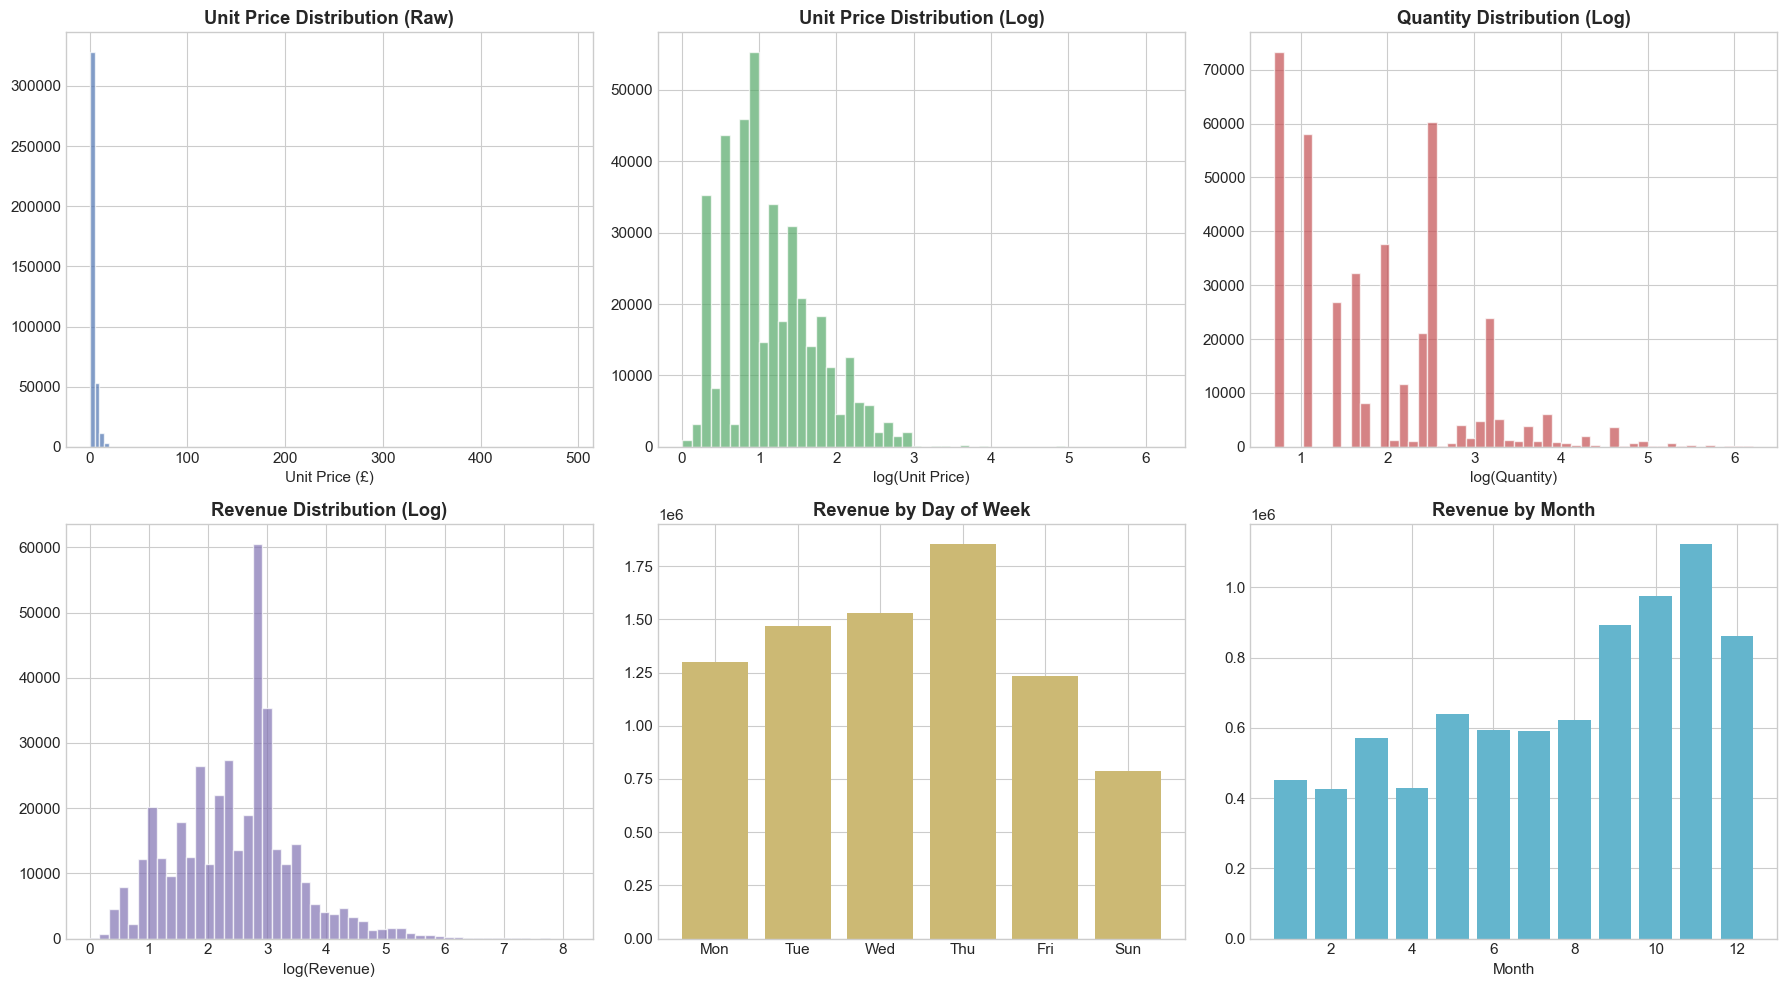

Chart saved: 01_distributions.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# UnitPrice distribution (raw)
axes[0, 0].hist(df['UnitPrice'], bins=100, color='#4C72B0', edgecolor='white', alpha=0.7)
axes[0, 0].set_title('Unit Price Distribution (Raw)', fontweight='bold')
axes[0, 0].set_xlabel('Unit Price (£)')

# UnitPrice distribution (log)
axes[0, 1].hist(np.log1p(df['UnitPrice']), bins=50, color='#55A868', edgecolor='white', alpha=0.7)
axes[0, 1].set_title('Unit Price Distribution (Log)', fontweight='bold')
axes[0, 1].set_xlabel('log(Unit Price)')

# Quantity distribution (log)
axes[0, 2].hist(np.log1p(df['Quantity']), bins=50, color='#C44E52', edgecolor='white', alpha=0.7)
axes[0, 2].set_title('Quantity Distribution (Log)', fontweight='bold')
axes[0, 2].set_xlabel('log(Quantity)')

# Revenue distribution (log)
axes[1, 0].hist(np.log1p(df['Revenue']), bins=50, color='#8172B2', edgecolor='white', alpha=0.7)
axes[1, 0].set_title('Revenue Distribution (Log)', fontweight='bold')
axes[1, 0].set_xlabel('log(Revenue)')

# Sales by day of week
dow_sales = df.groupby('DayOfWeek')['Revenue'].sum()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1, 1].bar(range(len(dow_sales)), dow_sales.values, color='#CCB974',
               tick_label=[days[i] for i in dow_sales.index])
axes[1, 1].set_title('Revenue by Day of Week', fontweight='bold')

# Sales by month
monthly = df.groupby('Month')['Revenue'].sum()
axes[1, 2].bar(monthly.index, monthly.values, color='#64B5CD')
axes[1, 2].set_title('Revenue by Month', fontweight='bold')
axes[1, 2].set_xlabel('Month')

plt.tight_layout()
plt.savefig('01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 01_distributions.png")


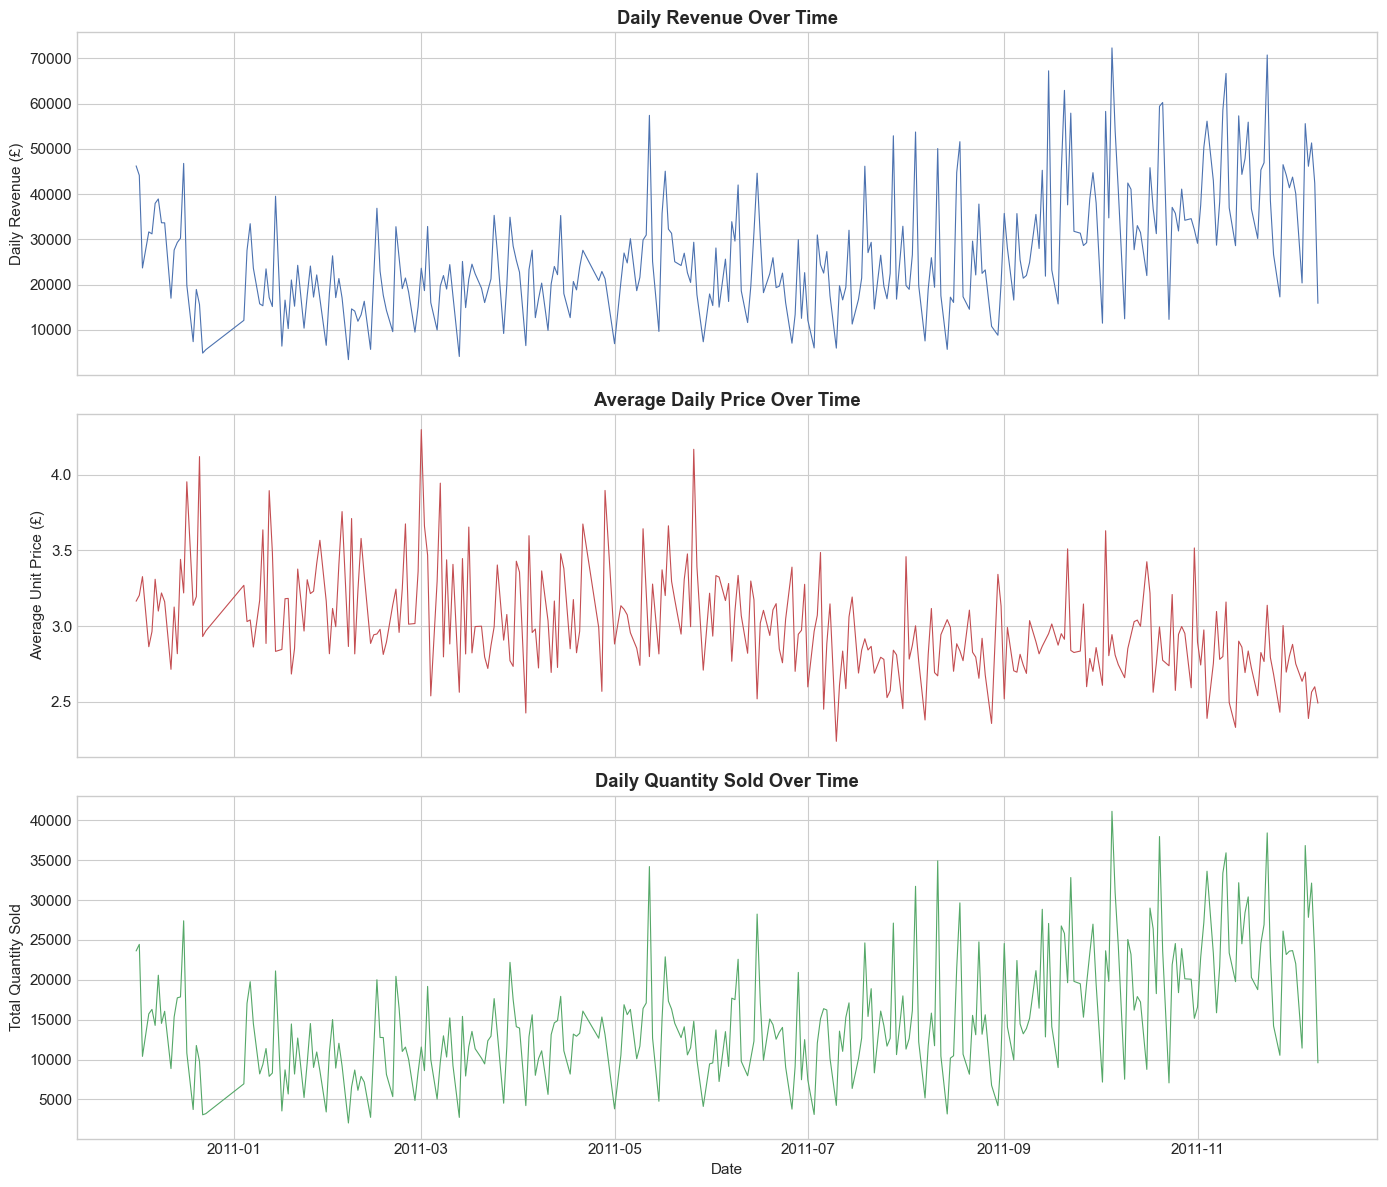

Chart saved: 02_time_series.png


In [6]:
daily = df.groupby('Date').agg(
    revenue=('Revenue', 'sum'),
    orders=('InvoiceNo', 'nunique'),
    avg_price=('UnitPrice', 'mean'),
    total_qty=('Quantity', 'sum')
).reset_index()
daily['Date'] = pd.to_datetime(daily['Date'])

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(daily['Date'], daily['revenue'], color='#4C72B0', linewidth=0.8)
axes[0].set_ylabel('Daily Revenue (£)')
axes[0].set_title('Daily Revenue Over Time', fontweight='bold')

axes[1].plot(daily['Date'], daily['avg_price'], color='#C44E52', linewidth=0.8)
axes[1].set_ylabel('Average Unit Price (£)')
axes[1].set_title('Average Daily Price Over Time', fontweight='bold')

axes[2].plot(daily['Date'], daily['total_qty'], color='#55A868', linewidth=0.8)
axes[2].set_ylabel('Total Quantity Sold')
axes[2].set_title('Daily Quantity Sold Over Time', fontweight='bold')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.savefig('02_time_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 02_time_series.png")


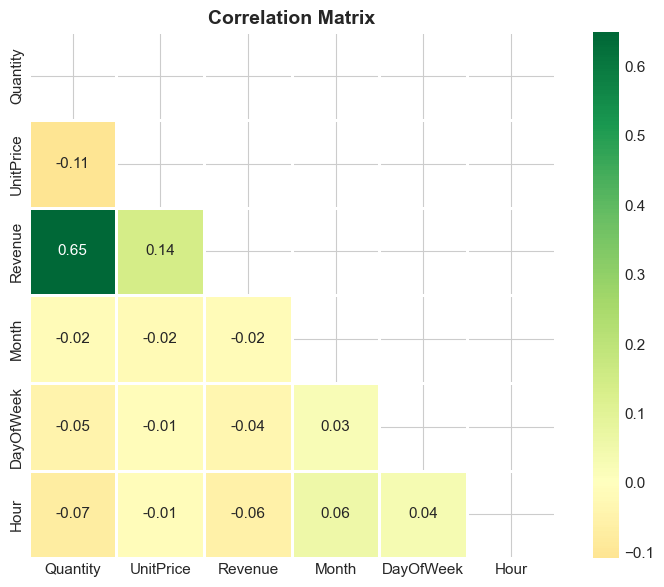

Chart saved: 03_correlation_matrix.png

Key: Price-Quantity correlation = -0.108
→ Weak negative correlation: higher prices are weakly associated with lower quantities
  But correlation ≠ causation — we need regression to control for confounders.


In [7]:
corr_cols = ['Quantity', 'UnitPrice', 'Revenue', 'Month', 'DayOfWeek', 'Hour']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=1, ax=ax)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 03_correlation_matrix.png")

print(f"\nKey: Price-Quantity correlation = {corr_matrix.loc['UnitPrice', 'Quantity']:.3f}")
print("→ Weak negative correlation: higher prices are weakly associated with lower quantities")
print("  But correlation ≠ causation — we need regression to control for confounders.")


In [8]:
df['Week'] = df['InvoiceDate'].dt.isocalendar().week.astype(int)
df['Year'] = df['InvoiceDate'].dt.year

product_weeks = df.groupby('StockCode')['Week'].nunique()
active_products = product_weeks[product_weeks >= 20].index
df_active = df[df['StockCode'].isin(active_products)]

print(f"Active products (≥20 weeks of data): {len(active_products)}")
print(f"Transactions retained: {len(df_active):,} ({len(df_active)/len(df)*100:.1f}%)")

# Aggregate to product-week level
product_week = df_active.groupby(['StockCode', 'Year', 'Week']).agg(
    avg_price=('UnitPrice', 'mean'),
    total_qty=('Quantity', 'sum'),
    revenue=('Revenue', 'sum'),
    num_transactions=('InvoiceNo', 'nunique'),
    num_customers=('CustomerID', 'nunique'),
    month=('Month', 'first'),
    quarter=('Quarter', 'first')
).reset_index()

print(f"\nProduct-week observations: {len(product_week):,}")
product_week.head()


Active products (≥20 weeks of data): 1918
Transactions retained: 353,609 (89.0%)

Product-week observations: 72,050


,StockCode,Year,Week,avg_price,total_qty,revenue,num_transactions,num_customers,month,quarter
0,10125,2010,48,0.85,2,1.70,1,1,12,4
1,10125,2010,49,0.85,41,34.85,3,3,12,4
2,10125,2010,50,0.42,100,42.00,3,3,12,4
3,10125,2011,1,0.42,80,33.60,3,3,1,1
4,10125,2011,2,0.42,60,25.20,3,3,1,1


In [9]:
product_week['log_price'] = np.log(product_week['avg_price'])
product_week['log_qty'] = np.log(product_week['total_qty'])
product_week['log_revenue'] = np.log(product_week['revenue'])


product_week = product_week.sort_values(['StockCode', 'Year', 'Week'])
product_week['price_lag1'] = product_week.groupby('StockCode')['avg_price'].shift(1)
product_week['price_change_pct'] = (
    (product_week['avg_price'] - product_week['price_lag1']) / product_week['price_lag1'] * 100
)

product_week['qty_lag1'] = product_week.groupby('StockCode')['total_qty'].shift(1)
product_week['log_qty_lag1'] = np.log(product_week['qty_lag1'].clip(lower=1))

print("Price elasticity proxies created:")
print(f"  log_price, log_qty, log_revenue")
print(f"  price_change_pct (week-over-week)")
print(f"  qty_lag1 (lagged quantity for momentum)")


Price elasticity proxies created:
  log_price, log_qty, log_revenue
  price_change_pct (week-over-week)
  qty_lag1 (lagged quantity for momentum)


In [10]:
product_week['is_promotion'] = (product_week['price_change_pct'] < -10).astype(int)

promo_pct = product_week['is_promotion'].mean() * 100
print(f"Promotion flag created:")
print(f"  Definition: price drop > 10% week-over-week")
print(f"  Observations with promotion: {promo_pct:.1f}%")
print(f"  Avg qty when promoted:     {product_week[product_week['is_promotion']==1]['total_qty'].mean():.0f}")
print(f"  Avg qty when not promoted: {product_week[product_week['is_promotion']==0]['total_qty'].mean():.0f}")


Promotion flag created:
  Definition: price drop > 10% week-over-week
  Observations with promotion: 4.1%
  Avg qty when promoted:     77
  Avg qty when not promoted: 57


In [11]:
product_week['Q2'] = (product_week['quarter'] == 2).astype(int)
product_week['Q3'] = (product_week['quarter'] == 3).astype(int)
product_week['Q4'] = (product_week['quarter'] == 4).astype(int)

product_week['is_peak_season'] = product_week['month'].isin([10, 11]).astype(int)

product_week['price_x_promo'] = product_week['log_price'] * product_week['is_promotion']

product_week['price_x_peak'] = product_week['log_price'] * product_week['is_peak_season']

model_data = product_week.dropna(subset=[
    'log_price', 'log_qty', 'price_change_pct', 'log_qty_lag1'
]).copy()

model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna(subset=[
    'log_price', 'log_qty', 'log_qty_lag1'
])

print(f"Final model dataset: {len(model_data):,} observations")
print(f"\nFeatures created:")
print(f"  Seasonal: Q2, Q3, Q4, is_peak_season")
print(f"  Interactions: price_x_promo, price_x_peak")
print(f"  Controls: log_qty_lag1 (momentum), num_customers")


Final model dataset: 70,132 observations

Features created:
  Seasonal: Q2, Q3, Q4, is_peak_season
  Interactions: price_x_promo, price_x_peak
  Controls: log_qty_lag1 (momentum), num_customers


In [12]:
formula_base = (
    'log_qty ~ log_price + is_promotion + Q2 + Q3 + Q4 + '
    'is_peak_season + log_qty_lag1'
)

model_base = smf.ols(formula_base, data=model_data).fit()

print("=" * 70)
print("BASE MODEL: log(Quantity) ~ log(Price) + Controls")
print("=" * 70)
print(model_base.summary())


BASE MODEL: log(Quantity) ~ log(Price) + Controls
                            OLS Regression Results                            
Dep. Variable:                log_qty   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     6735.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        04:16:36   Log-Likelihood:            -1.1163e+05
No. Observations:               70132   AIC:                         2.233e+05
Df Residuals:                   70124   BIC:                         2.234e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [13]:
formula_full = (
    'log_qty ~ log_price + is_promotion + Q2 + Q3 + Q4 + '
    'is_peak_season + price_x_promo + price_x_peak + log_qty_lag1'
)

model_full = smf.ols(formula_full, data=model_data).fit()

print("=" * 70)
print("FULL MODEL: With Interaction Terms")
print("=" * 70)
print(model_full.summary())


FULL MODEL: With Interaction Terms
                            OLS Regression Results                            
Dep. Variable:                log_qty   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     5239.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        04:16:36   Log-Likelihood:            -1.1163e+05
No. Observations:               70132   AIC:                         2.233e+05
Df Residuals:                   70122   BIC:                         2.234e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept

In [14]:
model_robust = smf.ols(formula_full, data=model_data).fit(cov_type='HC1')

print("=" * 70)
print("FULL MODEL WITH ROBUST STANDARD ERRORS (HC1)")
print("=" * 70)
print(model_robust.summary())

FULL MODEL WITH ROBUST STANDARD ERRORS (HC1)
                            OLS Regression Results                            
Dep. Variable:                log_qty   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     5508.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        04:16:37   Log-Likelihood:            -1.1163e+05
No. Observations:               70132   AIC:                         2.233e+05
Df Residuals:                   70122   BIC:                         2.234e+05
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------

In [15]:
print("=" * 70)
print("KEY COEFFICIENT INTERPRETATION")
print("=" * 70)

coefs = model_robust.params
conf = model_robust.conf_int()
pvals = model_robust.pvalues

results = []
for var in ['log_price', 'is_promotion', 'Q4', 'is_peak_season', 'price_x_promo']:
    sig = "***" if pvals[var] < 0.01 else "**" if pvals[var] < 0.05 else "*" if pvals[var] < 0.1 else ""
    results.append({
        'Variable': var,
        'Coefficient': coefs[var],
        'CI_Lower': conf.loc[var, 0],
        'CI_Upper': conf.loc[var, 1],
        'P_Value': pvals[var],
        'Sig': sig
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

elasticity = coefs['log_price']
print(f"\n{'='*70}")
print(f"PRICE ELASTICITY OF DEMAND: {elasticity:.3f}")
print(f"{'='*70}")
print(f"Interpretation: A 1% increase in price leads to a {elasticity:.2f}% change in quantity.")

if abs(elasticity) > 1:
    print(f"Demand is ELASTIC (|{elasticity:.2f}| > 1): Price increases hurt revenue.")
    print(f"→ Recommendation: Consider lowering prices to increase total revenue.")
elif abs(elasticity) < 1:
    print(f"Demand is INELASTIC (|{elasticity:.2f}| < 1): Price increases boost revenue.")
    print(f"→ Recommendation: There is room to raise prices without losing much volume.")
else:
    print(f"Demand is UNIT ELASTIC: Revenue is maximized at current pricing.")


KEY COEFFICIENT INTERPRETATION
      Variable  Coefficient  CI_Lower  CI_Upper       P_Value Sig
     log_price    -0.239540 -0.250119 -0.228961  0.000000e+00 ***
  is_promotion     0.741907  0.688594  0.795219 8.302539e-164 ***
            Q4    -0.119599 -0.159641 -0.079557  4.796530e-09 ***
is_peak_season     0.142320  0.099576  0.185065  6.764256e-11 ***
 price_x_promo    -0.007870 -0.054705  0.038965  7.419040e-01    

PRICE ELASTICITY OF DEMAND: -0.240
Interpretation: A 1% increase in price leads to a -0.24% change in quantity.
Demand is INELASTIC (|-0.24| < 1): Price increases boost revenue.
→ Recommendation: There is room to raise prices without losing much volume.


In [16]:
X_vars = ['log_price', 'is_promotion', 'Q2', 'Q3', 'Q4',
          'is_peak_season', 'price_x_promo', 'price_x_peak', 'log_qty_lag1']
X_vif = model_data[X_vars].copy()
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame({
    'Variable': X_vif.columns[1:],  # skip constant
    'VIF': [variance_inflation_factor(X_vif.values, i+1) for i in range(len(X_vars))]
})
vif_data['Status'] = vif_data['VIF'].apply(
    lambda x: 'OK' if x < 5 else 'MODERATE' if x < 10 else 'HIGH'
)

print("VARIANCE INFLATION FACTORS")
print("=" * 50)
print(vif_data.to_string(index=False))
print("\nRule: VIF < 5 = OK, 5-10 = moderate concern, > 10 = problem")


VARIANCE INFLATION FACTORS
      Variable      VIF Status
     log_price 1.427681     OK
  is_promotion 1.148089     OK
            Q2 1.574460     OK
            Q3 1.618552     OK
            Q4 3.798592     OK
is_peak_season 3.472248     OK
 price_x_promo 1.161266     OK
  price_x_peak 1.590803     OK
  log_qty_lag1 1.128959     OK

Rule: VIF < 5 = OK, 5-10 = moderate concern, > 10 = problem


In [17]:
residuals = model_full.resid
fitted = model_full.fittedvalues
exog = model_full.model.exog

bp_test = het_breuschpagan(residuals, exog)
bp_stat, bp_pvalue, bp_fstat, bp_fpvalue = bp_test

print("BREUSCH-PAGAN TEST FOR HETEROSCEDASTICITY")
print("=" * 50)
print(f"Test statistic: {bp_stat:.4f}")
print(f"P-value:        {bp_pvalue:.6f}")

if bp_pvalue < 0.05:
    print("\n→ RESULT: Heteroscedasticity detected (p < 0.05)")
    print("  This is why we use ROBUST standard errors (HC1) — they remain")
    print("  valid even when variance is not constant.")
    print("  Our model_robust results already account for this.")
else:
    print("\n→ RESULT: No evidence of heteroscedasticity (p > 0.05)")


BREUSCH-PAGAN TEST FOR HETEROSCEDASTICITY
Test statistic: 335.2813
P-value:        0.000000

→ RESULT: Heteroscedasticity detected (p < 0.05)
  This is why we use ROBUST standard errors (HC1) — they remain
  valid even when variance is not constant.
  Our model_robust results already account for this.


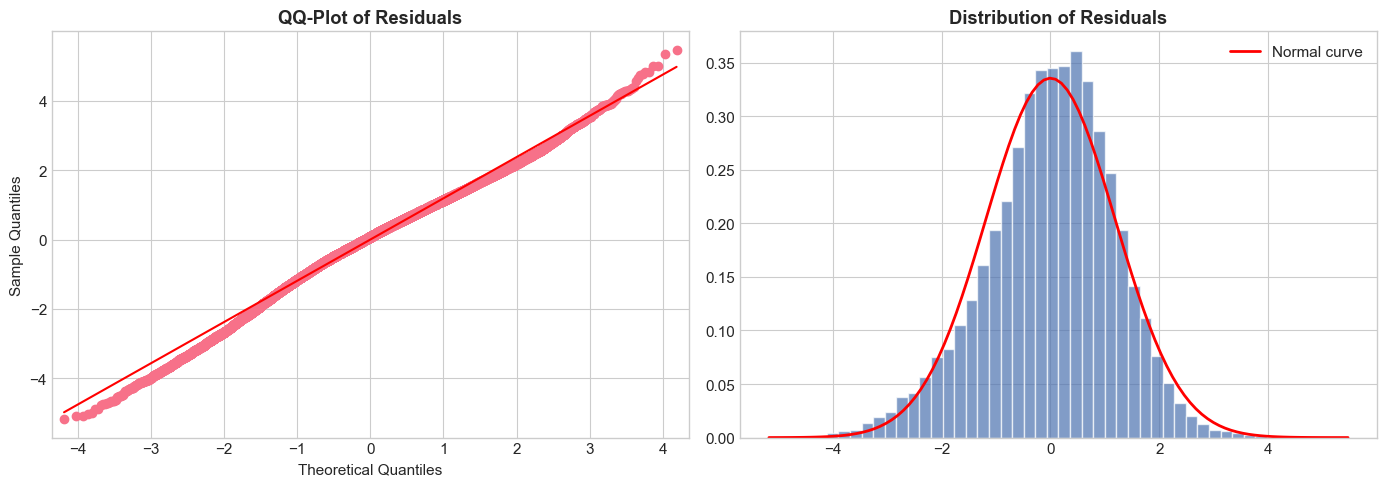

SHAPIRO-WILK TEST FOR NORMALITY
Test statistic: 0.9944
P-value:        0.000000

→ Residuals are NOT perfectly normal.
  This is common with large datasets. By the Central Limit Theorem,
  OLS coefficient estimates are still approximately normal for large n.
  Our robust standard errors also help mitigate this issue.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# QQ-Plot: if residuals are normal, points follow the diagonal line
sm.qqplot(residuals, line='s', ax=axes[0])
axes[0].set_title('QQ-Plot of Residuals', fontweight='bold')

# Histogram of residuals
axes[1].hist(residuals, bins=50, density=True, color='#4C72B0', edgecolor='white', alpha=0.7)
x_range = np.linspace(residuals.min(), residuals.max(), 100)
axes[1].plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()),
             'r-', linewidth=2, label='Normal curve')
axes[1].set_title('Distribution of Residuals', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('04_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Shapiro-Wilk test (on a sample — test is unreliable with >5000 observations)
sample_resid = np.random.choice(residuals, size=min(5000, len(residuals)), replace=False)
shapiro_stat, shapiro_p = stats.shapiro(sample_resid)

print("SHAPIRO-WILK TEST FOR NORMALITY")
print("=" * 50)
print(f"Test statistic: {shapiro_stat:.4f}")
print(f"P-value:        {shapiro_p:.6f}")

if shapiro_p < 0.05:
    print("\n→ Residuals are NOT perfectly normal.")
    print("  This is common with large datasets. By the Central Limit Theorem,")
    print("  OLS coefficient estimates are still approximately normal for large n.")
    print("  Our robust standard errors also help mitigate this issue.")
else:
    print("\n→ Residuals appear approximately normal.")


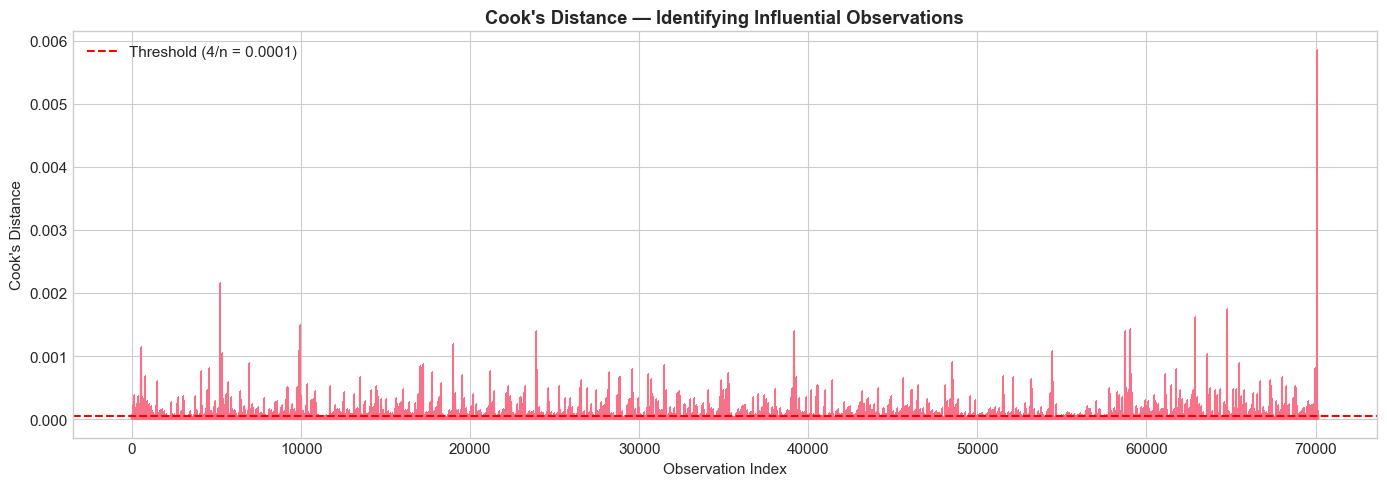

Influential observations (Cook's D > 0.0001): 3264
Percentage: 4.7%

→ If < 5%, the model is not unduly influenced by outliers.


In [19]:
influence = model_full.get_influence()
cooks_d = influence.cooks_distance[0]
n = len(model_data)
threshold = 4 / n

fig, ax = plt.subplots(figsize=(14, 5))
ax.stem(range(len(cooks_d)), cooks_d, markerfmt=',', linefmt='C0-', basefmt='C0-')
ax.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold (4/n = {threshold:.4f})')
ax.set_title("Cook's Distance — Identifying Influential Observations", fontweight='bold')
ax.set_xlabel('Observation Index')
ax.set_ylabel("Cook's Distance")
ax.legend()
plt.tight_layout()
plt.savefig('05_cooks_distance.png', dpi=150, bbox_inches='tight')
plt.show()

n_influential = (cooks_d > threshold).sum()
print(f"Influential observations (Cook's D > {threshold:.4f}): {n_influential}")
print(f"Percentage: {n_influential/n*100:.1f}%")
print("\n→ If < 5%, the model is not unduly influenced by outliers.")


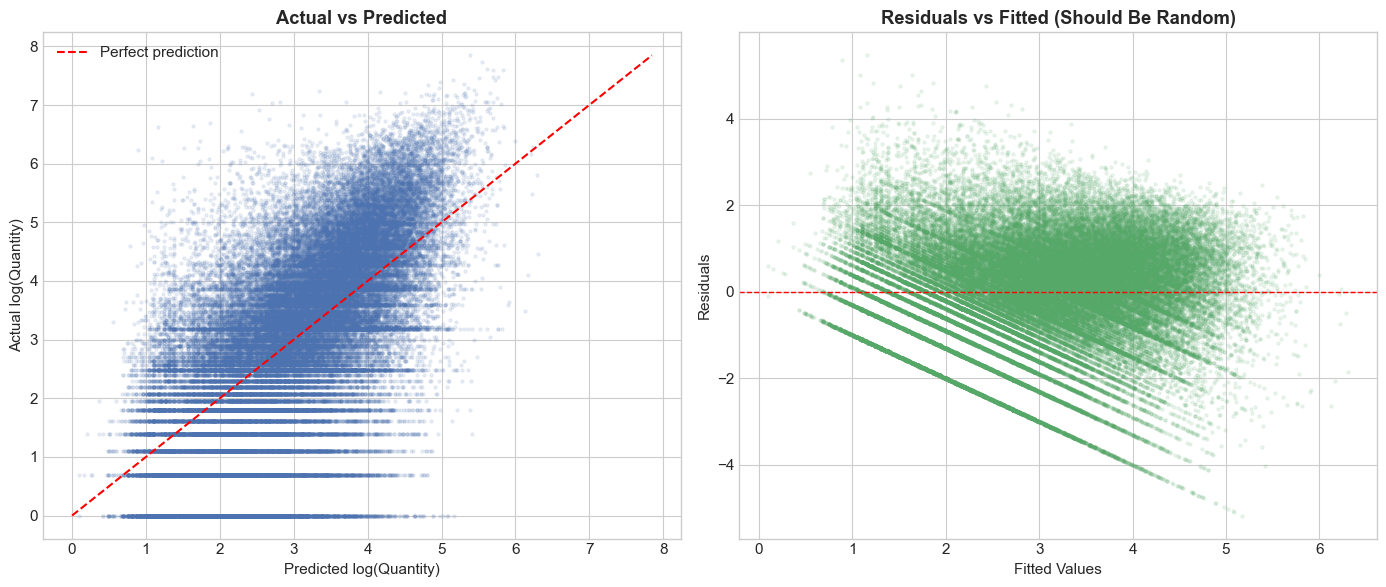

Chart saved: 06_actual_vs_predicted.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Actual vs Predicted
axes[0].scatter(fitted, model_data['log_qty'], alpha=0.1, s=5, color='#4C72B0')
min_val = min(fitted.min(), model_data['log_qty'].min())
max_val = max(fitted.max(), model_data['log_qty'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Predicted log(Quantity)')
axes[0].set_ylabel('Actual log(Quantity)')
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].legend()

# Residuals vs Fitted (check for patterns)
axes[1].scatter(fitted, residuals, alpha=0.1, s=5, color='#55A868')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Fitted (Should Be Random)', fontweight='bold')

plt.tight_layout()
plt.savefig('06_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 06_actual_vs_predicted.png")


In [21]:
print("HYPOTHESIS TESTS ON COEFFICIENTS")
print("=" * 80)
print(f"{'Variable':<20} {'Coef':>8} {'Std Err':>8} {'t-stat':>8} {'p-value':>10} {'Result':>15}")
print("-" * 80)

for var in model_robust.params.index:
    coef = model_robust.params[var]
    se = model_robust.bse[var]
    t = model_robust.tvalues[var]
    p = model_robust.pvalues[var]
    result = "SIGNIFICANT" if p < 0.05 else "not sig."
    print(f"{var:<20} {coef:>8.4f} {se:>8.4f} {t:>8.2f} {p:>10.6f} {result:>15}")

print(f"\n{'='*80}")
print(f"F-statistic: {model_robust.fvalue:.2f}")
print(f"Prob (F-stat): {model_robust.f_pvalue:.2e}")
print(f"\n→ The F-test confirms the model as a whole is statistically significant.")


HYPOTHESIS TESTS ON COEFFICIENTS
Variable                 Coef  Std Err   t-stat    p-value          Result
--------------------------------------------------------------------------------
Intercept              1.4183   0.0148    95.53   0.000000     SIGNIFICANT
log_price             -0.2395   0.0054   -44.38   0.000000     SIGNIFICANT
is_promotion           0.7419   0.0272    27.28   0.000000     SIGNIFICANT
Q2                    -0.0566   0.0132    -4.30   0.000017     SIGNIFICANT
Q3                     0.0127   0.0128     0.99   0.321869        not sig.
Q4                    -0.1196   0.0204    -5.85   0.000000     SIGNIFICANT
is_peak_season         0.1423   0.0218     6.53   0.000000     SIGNIFICANT
price_x_promo         -0.0079   0.0239    -0.33   0.741904        not sig.
price_x_peak           0.0310   0.0110     2.82   0.004823     SIGNIFICANT
log_qty_lag1           0.5691   0.0033   174.16   0.000000     SIGNIFICANT

F-statistic: 5507.98
Prob (F-stat): 0.00e+00

→ The F-test c

In [22]:
elasticity = model_robust.params['log_price']
ci = model_robust.conf_int().loc['log_price']

print("PRICE ELASTICITY WITH 95% CONFIDENCE INTERVAL")
print("=" * 60)
print(f"Point estimate: {elasticity:.4f}")
print(f"95% CI:         [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"\nInterpretation:")
print(f"  We are 95% confident that a 1% price increase leads to")
print(f"  between a {abs(ci[1]):.2f}% and {abs(ci[0]):.2f}% decrease in quantity demanded.")

# Business translation
for pct in [5, 10, 15]:
    qty_change = elasticity * pct
    print(f"\n  A {pct}% price increase → {qty_change:.1f}% change in quantity")


PRICE ELASTICITY WITH 95% CONFIDENCE INTERVAL
Point estimate: -0.2395
95% CI:         [-0.2501, -0.2290]

Interpretation:
  We are 95% confident that a 1% price increase leads to
  between a 0.23% and 0.25% decrease in quantity demanded.

  A 5% price increase → -1.2% change in quantity

  A 10% price increase → -2.4% change in quantity

  A 15% price increase → -3.6% change in quantity


In [23]:
elasticity = model_robust.params['log_price']
promo_effect = model_robust.params['is_promotion']

# Current baseline
current_avg_price = model_data['avg_price'].mean()
current_avg_qty = model_data['total_qty'].mean()
current_revenue = current_avg_price * current_avg_qty

scenarios = []
for price_change_pct in np.arange(-20, 21, 5):
    # New price
    new_price = current_avg_price * (1 + price_change_pct / 100)

    # Predicted quantity change using elasticity
    qty_change_pct = elasticity * price_change_pct  # log-log elasticity
    new_qty = current_avg_qty * (1 + qty_change_pct / 100)

    # New revenue
    new_revenue = new_price * new_qty
    revenue_change_pct = (new_revenue - current_revenue) / current_revenue * 100

    scenarios.append({
        'Price Change (%)': price_change_pct,
        'New Price (£)': round(new_price, 2),
        'Qty Change (%)': round(qty_change_pct, 1),
        'New Qty': round(new_qty, 0),
        'Revenue Change (%)': round(revenue_change_pct, 1)
    })

scenarios_df = pd.DataFrame(scenarios)
print("COUNTERFACTUAL REVENUE SIMULATIONS")
print("=" * 70)
print(scenarios_df.to_string(index=False))

# Find revenue-maximizing price change
best = scenarios_df.loc[scenarios_df['Revenue Change (%)'].idxmax()]
print(f"\n→ Revenue-maximizing price change: {best['Price Change (%)']:.0f}%")
print(f"  Expected revenue impact: {best['Revenue Change (%)']:.1f}%")


COUNTERFACTUAL REVENUE SIMULATIONS
 Price Change (%)  New Price (£)  Qty Change (%)  New Qty  Revenue Change (%)
              -20           2.34             4.8     61.0               -16.2
              -15           2.48             3.6     60.0               -11.9
              -10           2.63             2.4     60.0                -7.8
               -5           2.78             1.2     59.0                -3.9
                0           2.92            -0.0     58.0                 0.0
                5           3.07            -1.2     58.0                 3.7
               10           3.22            -2.4     57.0                 7.4
               15           3.36            -3.6     56.0                10.9
               20           3.51            -4.8     55.0                14.3

→ Revenue-maximizing price change: 20%
  Expected revenue impact: 14.3%


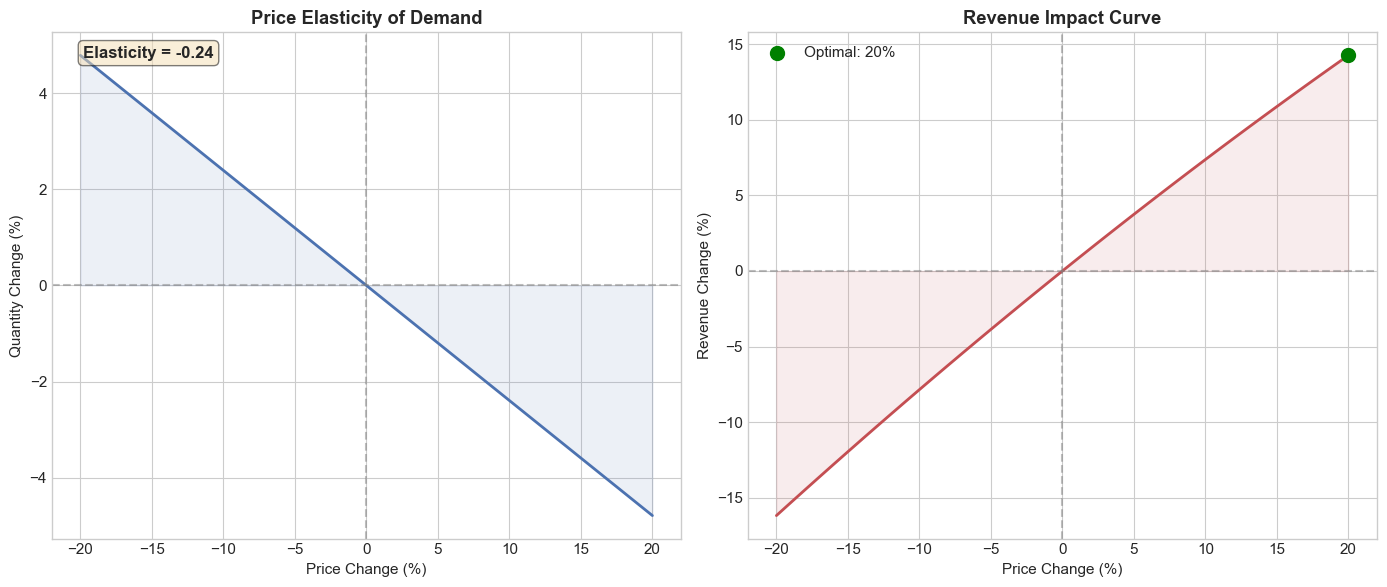

Chart saved: 07_elasticity_curves.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

price_changes = np.arange(-20, 21, 1)
qty_changes = elasticity * price_changes
revenue_changes = []

for pc in price_changes:
    new_p = current_avg_price * (1 + pc / 100)
    new_q = current_avg_qty * (1 + elasticity * pc / 100)
    new_r = new_p * new_q
    rev_chg = (new_r - current_revenue) / current_revenue * 100
    revenue_changes.append(rev_chg)

# Left: Demand curve (Price vs Quantity change)
axes[0].plot(price_changes, qty_changes, color='#4C72B0', linewidth=2)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0].fill_between(price_changes, qty_changes, alpha=0.1, color='#4C72B0')
axes[0].set_xlabel('Price Change (%)')
axes[0].set_ylabel('Quantity Change (%)')
axes[0].set_title('Price Elasticity of Demand', fontweight='bold')
axes[0].annotate(f'Elasticity = {elasticity:.2f}', xy=(0.05, 0.95),
                 xycoords='axes fraction', fontsize=12, fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Right: Revenue curve (Price vs Revenue change)
axes[1].plot(price_changes, revenue_changes, color='#C44E52', linewidth=2)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1].fill_between(price_changes, revenue_changes, alpha=0.1, color='#C44E52')
axes[1].set_xlabel('Price Change (%)')
axes[1].set_ylabel('Revenue Change (%)')
axes[1].set_title('Revenue Impact Curve', fontweight='bold')

# Mark the optimal point
opt_idx = np.argmax(revenue_changes)
axes[1].scatter([price_changes[opt_idx]], [revenue_changes[opt_idx]],
                color='green', s=100, zorder=5, label=f'Optimal: {price_changes[opt_idx]}%')
axes[1].legend()

plt.tight_layout()
plt.savefig('07_elasticity_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 07_elasticity_curves.png")


In [25]:
peak_coef = model_robust.params.get('is_peak_season', 0)
peak_ci = model_robust.conf_int().loc['is_peak_season'] if 'is_peak_season' in model_robust.params else [0, 0]

q4_coef = model_robust.params.get('Q4', 0)
promo_coef = model_robust.params.get('is_promotion', 0)

print("SEASONAL & PROMOTION EFFECTS")
print("=" * 60)
print(f"Peak Season (Oct-Nov) effect on log(Qty): {peak_coef:.4f}")
print(f"  → In peak season, quantity is ~{(np.exp(peak_coef)-1)*100:.1f}% higher, holding price constant")
print(f"  → 95% CI: [{(np.exp(peak_ci[0])-1)*100:.1f}%, {(np.exp(peak_ci[1])-1)*100:.1f}%]")
print(f"\nQ4 effect on log(Qty): {q4_coef:.4f}")
print(f"  → In Q4, quantity is ~{(np.exp(q4_coef)-1)*100:.1f}% higher than Q1")
print(f"\nPromotion effect on log(Qty): {promo_coef:.4f}")
print(f"  → Promotions increase quantity by ~{(np.exp(promo_coef)-1)*100:.1f}%")

print(f"\n{'='*60}")
print("SEASONAL PRICING RECOMMENDATION:")
print(f"{'='*60}")
print(f"During peak season (Oct-Nov), demand is naturally higher.")
print(f"If demand is elastic (|elasticity| > 1):")
print(f"  → OFF-season: Lower prices to stimulate demand")
print(f"  → PEAK season: Maintain or slightly raise prices (demand is robust)")
print(f"If demand is inelastic (|elasticity| < 1):")
print(f"  → Prices can be raised in all seasons without major volume loss")


SEASONAL & PROMOTION EFFECTS
Peak Season (Oct-Nov) effect on log(Qty): 0.1423
  → In peak season, quantity is ~15.3% higher, holding price constant
  → 95% CI: [10.5%, 20.3%]

Q4 effect on log(Qty): -0.1196
  → In Q4, quantity is ~-11.3% higher than Q1

Promotion effect on log(Qty): 0.7419
  → Promotions increase quantity by ~110.0%

SEASONAL PRICING RECOMMENDATION:
During peak season (Oct-Nov), demand is naturally higher.
If demand is elastic (|elasticity| > 1):
  → OFF-season: Lower prices to stimulate demand
  → PEAK season: Maintain or slightly raise prices (demand is robust)
If demand is inelastic (|elasticity| < 1):
  → Prices can be raised in all seasons without major volume loss


In [26]:
# Save results as CSV files (no compatibility issues)
coef_df = pd.DataFrame({
    'Variable': model_robust.params.index,
    'Coefficient': model_robust.params.values,
    'Std_Error': model_robust.bse.values,
    'T_Statistic': model_robust.tvalues.values,
    'P_Value': model_robust.pvalues.values,
    'CI_Lower': model_robust.conf_int().iloc[:, 0].values,
    'CI_Upper': model_robust.conf_int().iloc[:, 1].values
})

coef_df.to_csv('Regression_Results.csv', index=False)
scenarios_df.to_csv('Revenue_Scenarios.csv', index=False)
vif_data.to_csv('VIF_Diagnostics.csv', index=False)

print("Files saved:")
print("  1. Regression_Results.csv")
print("  2. Revenue_Scenarios.csv")
print("  3. VIF_Diagnostics.csv")
print("\n Can be opened to Excel or import into Power BI.")

Files saved:
  1. Regression_Results.csv
  2. Revenue_Scenarios.csv
  3. VIF_Diagnostics.csv

 Can be opened to Excel or import into Power BI.
